In [1]:
"""
mcPHASES — Script 1: Pre-Join EDA
===================================
Run BEFORE merging any tables.
Covers:
  A. Per-table raw distributions
  B. Per-participant coverage (days per table)
  C. Interval 1 vs Interval 2 comparison per table
  D. Missingness map per table

Recommended: Run in Jupyter (convert with: jupytext --to notebook script1_prejoin_eda.py)
or open in VS Code and use # %% cells interactively.
"""

'\nmcPHASES — Script 1: Pre-Join EDA\n===================================\nRun BEFORE merging any tables.\nCovers:\n  A. Per-table raw distributions\n  B. Per-participant coverage (days per table)\n  C. Interval 1 vs Interval 2 comparison per table\n  D. Missingness map per table\n\nRecommended: Run in Jupyter (convert with: jupytext --to notebook script1_prejoin_eda.py)\nor open in VS Code and use # %% cells interactively.\n'

In [2]:
# ─────────────────────────────────────────────
# 0. IMPORTS & CONFIG
# ─────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

In [3]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

In [4]:
DATA_DIR = "/Users/kikkiliu/physionet.org/files/mcphases/data"       # <-- change to your path
OUT_DIR  = "/Users/kikkiliu/physionet.org/files/mcphases/eda_outputs/script1_prejoin"
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
def savefig(name):
    plt.tight_layout()
    # plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight")
    plt.show()

In [6]:
def load(fname, **kwargs):
    path = os.path.join(DATA_DIR, fname)
    df   = pd.read_csv(path, **kwargs)
    print(f"  ✓ [{fname}]  shape={df.shape}")
    return df

In [7]:
# ─────────────────────────────────────────────
# LOAD ALL TABLES (raw, no aggregation)
# ─────────────────────────────────────────────
print("Loading tables …")
tables = {
    "active_minutes"        : load("active_minutes.csv"),
    "calories"              : load("calories.csv"),
    "distance"              : load("distance.csv"),
    "steps"                 : load("steps.csv"),
    "heart_rate"            : load("heart_rate.csv"),
    "glucose"               : load("glucose.csv"),
    "sleep"                 : load("sleep.csv"),
    "sleep_score"           : load("sleep_score.csv"),
    "stress_score"          : load("stress_score.csv"),
    "resting_heart_rate"    : load("resting_heart_rate.csv"),
    "wrist_temperature"     : load("wrist_temperature.csv"),
    "computed_temperature"  : load("computed_temperature.csv"),
    "respiratory_rate"      : load("respiratory_rate_summary.csv"),
    "hrv"                   : load("heart_rate_variability_details.csv"),
    "exercise"              : load("exercise.csv"),
    "vo2"                   : load("demographic_vo2_max.csv"),
    "hormones_selfreport"   : load("hormones_and_selfreport.csv"),
    "subject_info"          : load("subject-info.csv"),
}

Loading tables …
  ✓ [active_minutes.csv]  shape=(5552, 8)
  ✓ [calories.csv]  shape=(20166975, 6)
  ✓ [distance.csv]  shape=(7666949, 6)
  ✓ [steps.csv]  shape=(7666949, 6)
  ✓ [heart_rate.csv]  shape=(63100276, 7)
  ✓ [glucose.csv]  shape=(837130, 6)
  ✓ [sleep.csv]  shape=(14765, 18)
  ✓ [sleep_score.csv]  shape=(5308, 12)
  ✓ [stress_score.csv]  shape=(7932, 14)
  ✓ [resting_heart_rate.csv]  shape=(13737, 6)
  ✓ [wrist_temperature.csv]  shape=(6856019, 6)
  ✓ [computed_temperature.csv]  shape=(5575, 14)
  ✓ [respiratory_rate_summary.csv]  shape=(6301, 17)
  ✓ [heart_rate_variability_details.csv]  shape=(436262, 9)
  ✓ [exercise.csv]  shape=(7282, 26)
  ✓ [demographic_vo2_max.csv]  shape=(11482, 8)
  ✓ [hormones_and_selfreport.csv]  shape=(5659, 22)
  ✓ [subject-info.csv]  shape=(42, 8)


In [8]:
# Key columns we expect in most tables
ID_COL       = "id"
DAY_COL      = "day_in_study"
INTERVAL_COL = "study_interval"

In [9]:
# ═════════════════════════════════════════════
# A. PER-TABLE RAW DISTRIBUTIONS
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("A. PER-TABLE RAW DISTRIBUTIONS")
print("="*60)


A. PER-TABLE RAW DISTRIBUTIONS


In [10]:
# Define which numeric column(s) to plot as representative signal per table
TABLE_SIGNALS = {
    "active_minutes"       : ["sedentary", "lightly", "moderately", "very"],
    "calories"             : ["calories"],
    "distance"             : ["distance"],
    "steps"                : ["steps"],
    "heart_rate"           : ["bpm"],
    "glucose"              : ["glucose_value"],
    "sleep"                : ["minutesasleep", "efficiency", "minutestofallasleep"],
    "sleep_score"          : ["overall_score", "deep_sleep_in_minutes", "restlessness"],
    "stress_score"         : ["stress_score"],
    "resting_heart_rate"   : ["value"],
    "wrist_temperature"    : ["temperature_diff_from_baseline"],
    "computed_temperature" : ["nightly_temperature",
                              "baseline_relative_nightly_standard_deviation"],
    "respiratory_rate"     : ["full_sleep_breathing_rate",
                              "deep_sleep_breathing_rate", "rem_sleep_breathing_rate"],
    "hrv"                  : ["rmssd", "low_frequency", "high_frequency"],
    "vo2"                  : ["demographic_vo2_max", "filtered_demographic_vo2_max"],
    "hormones_selfreport"  : ["lh", "estrogen", "pdg"],
}

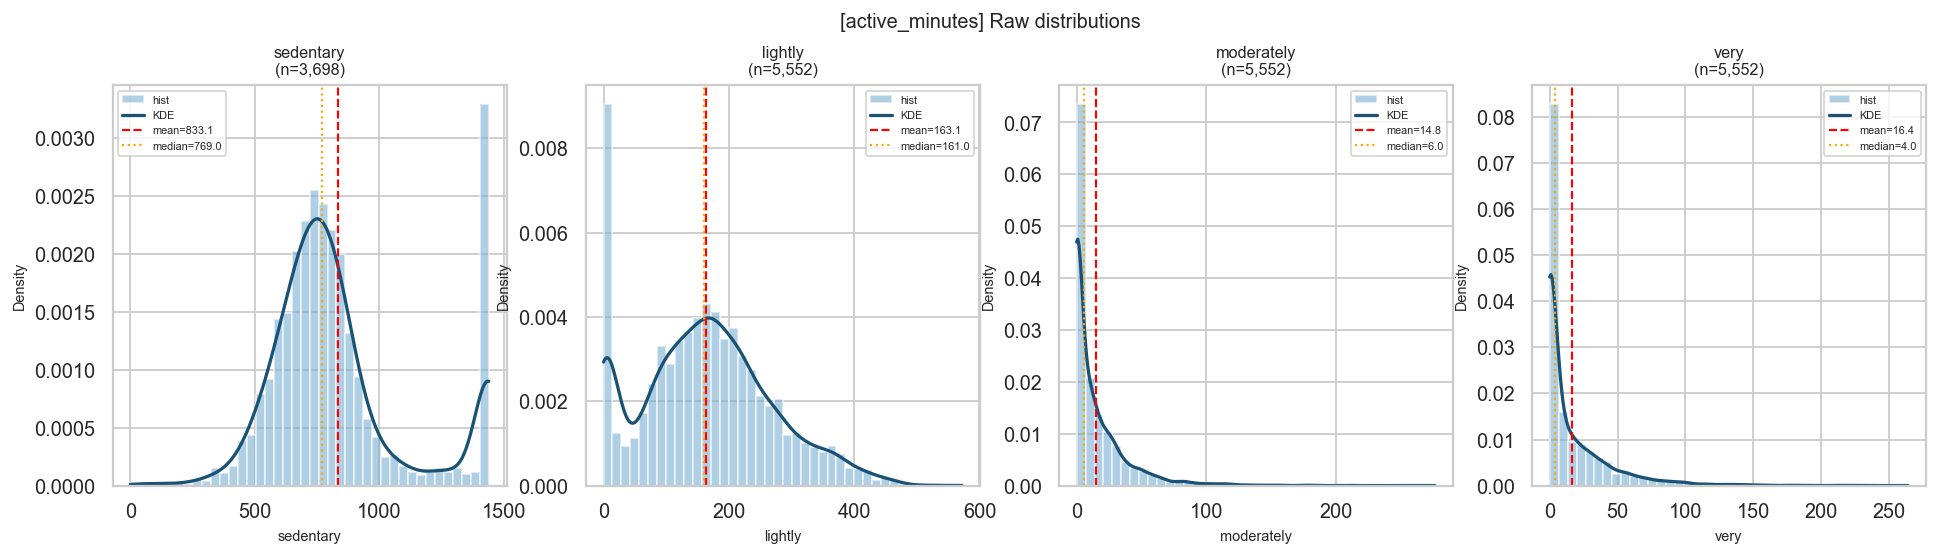

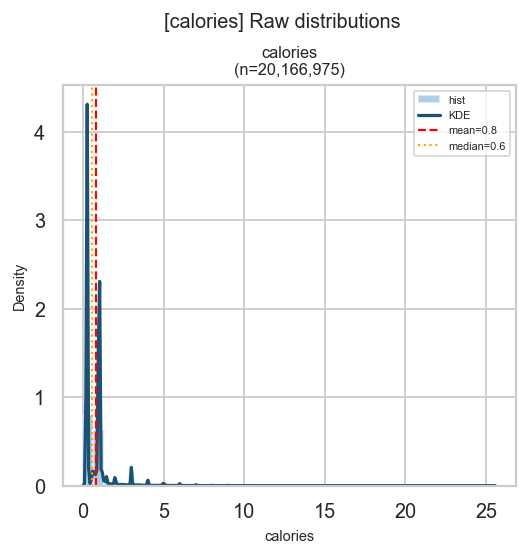

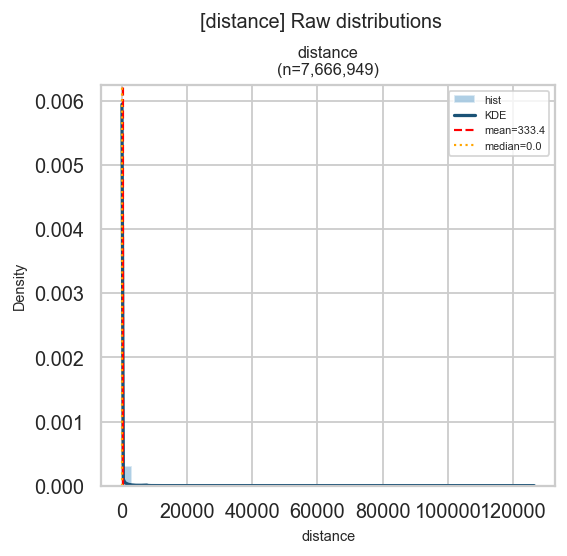

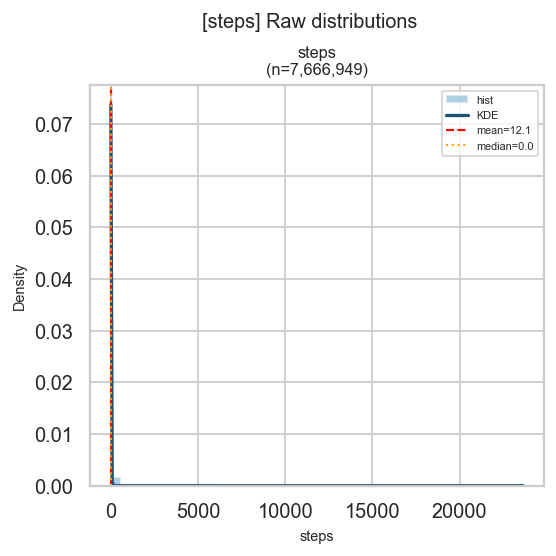

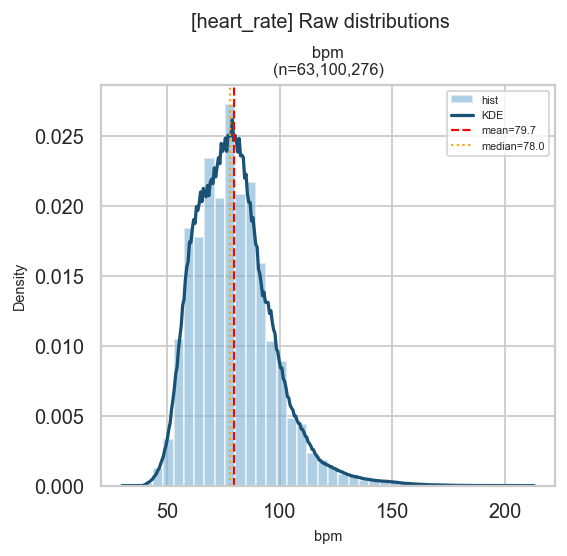

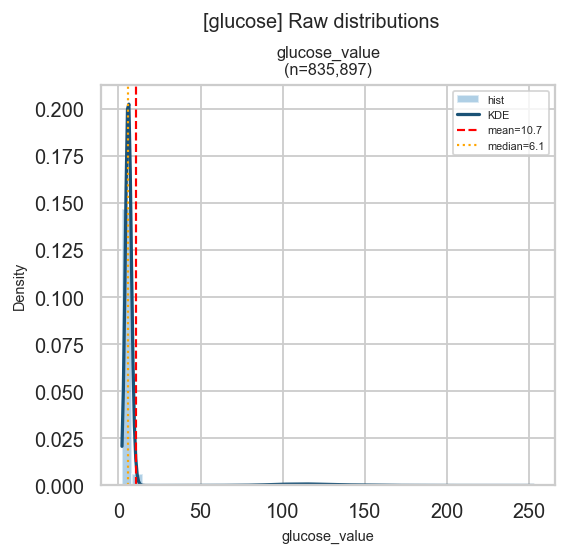

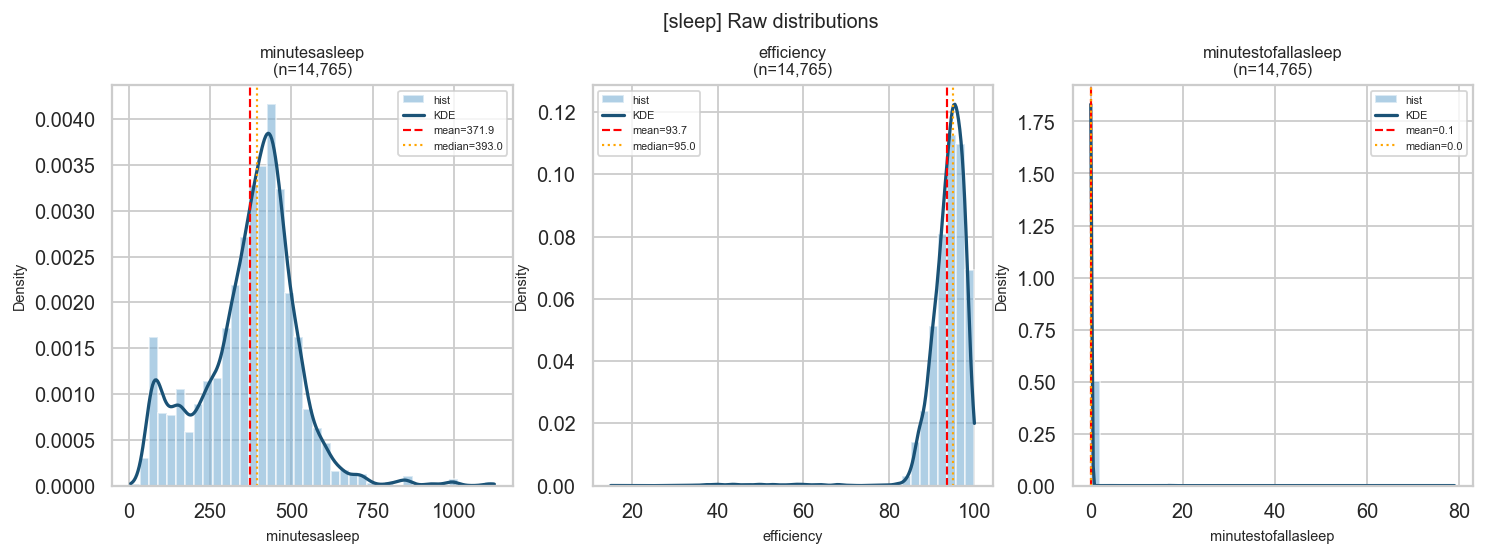

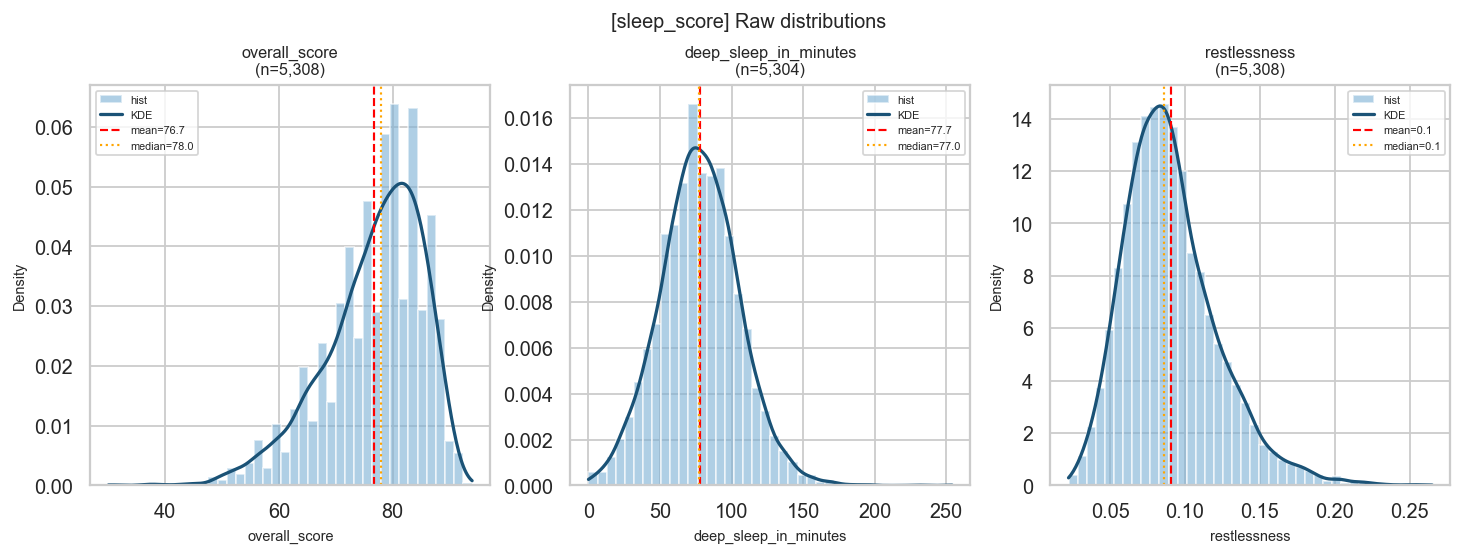

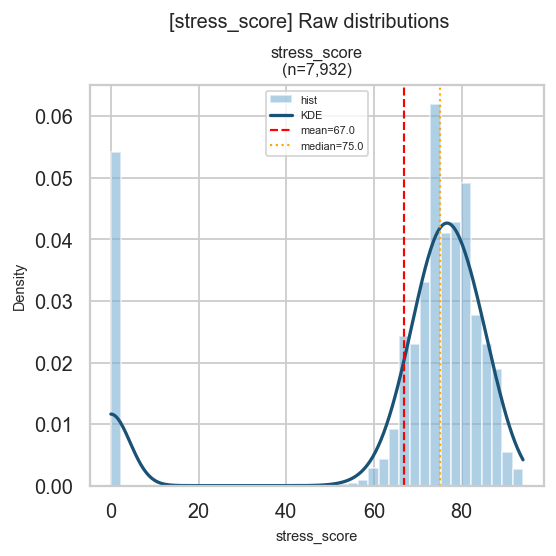

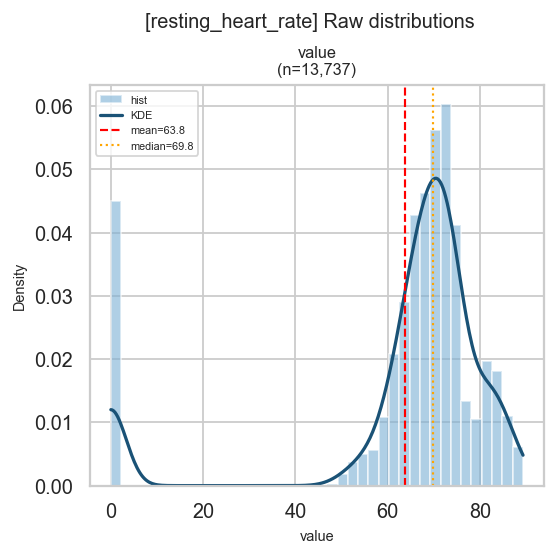

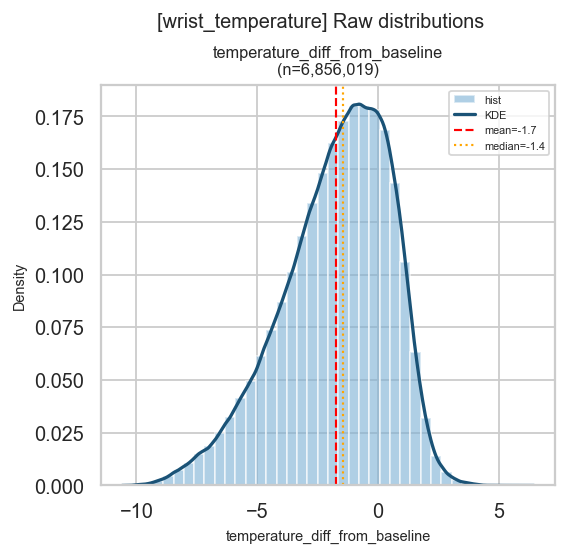

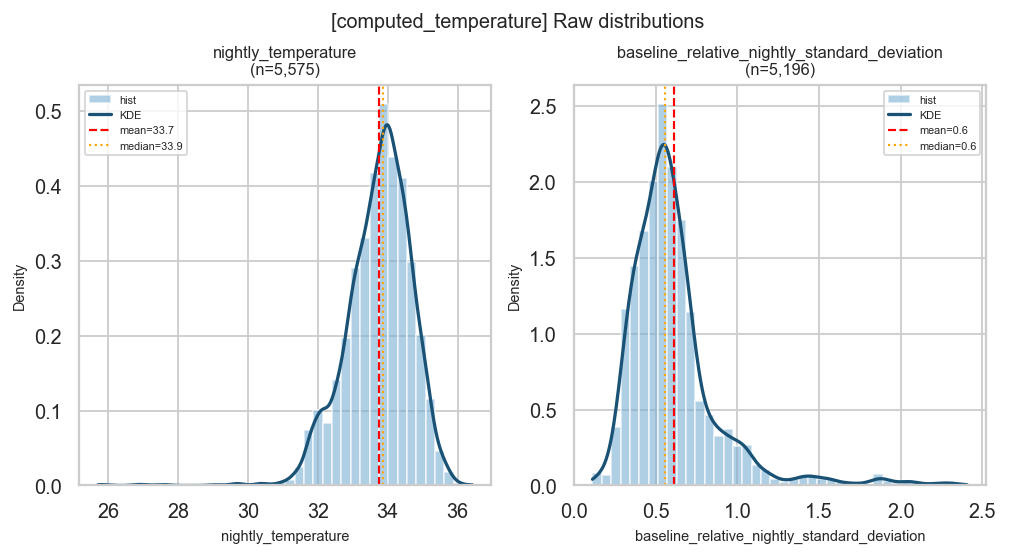

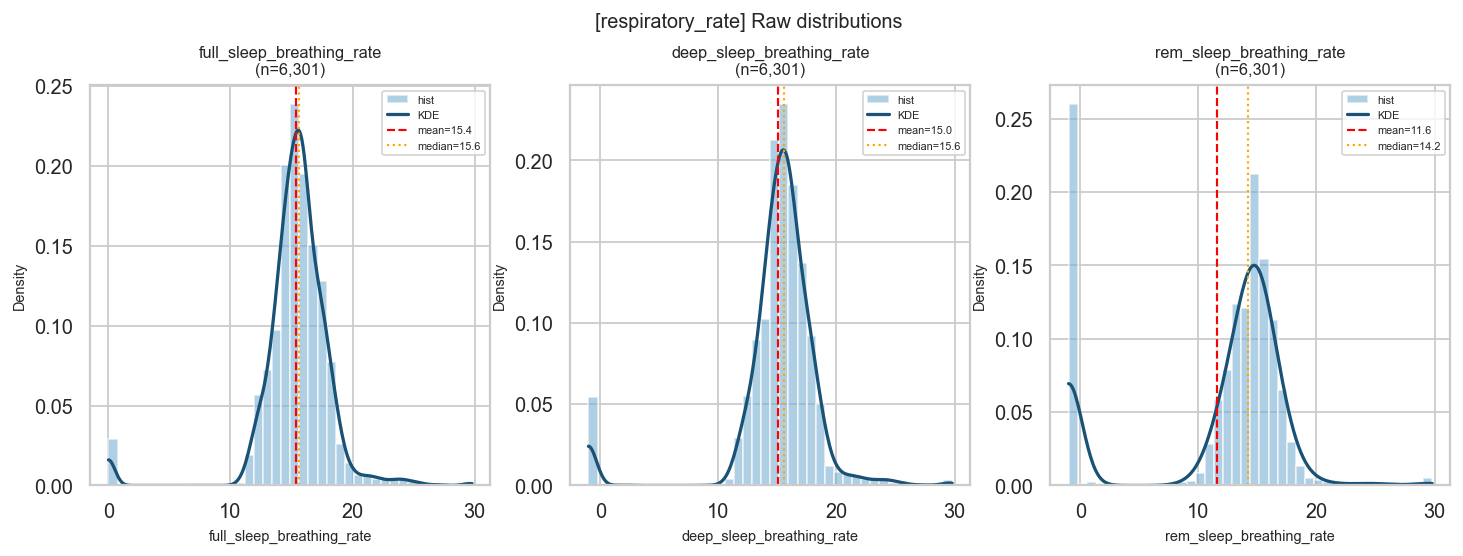

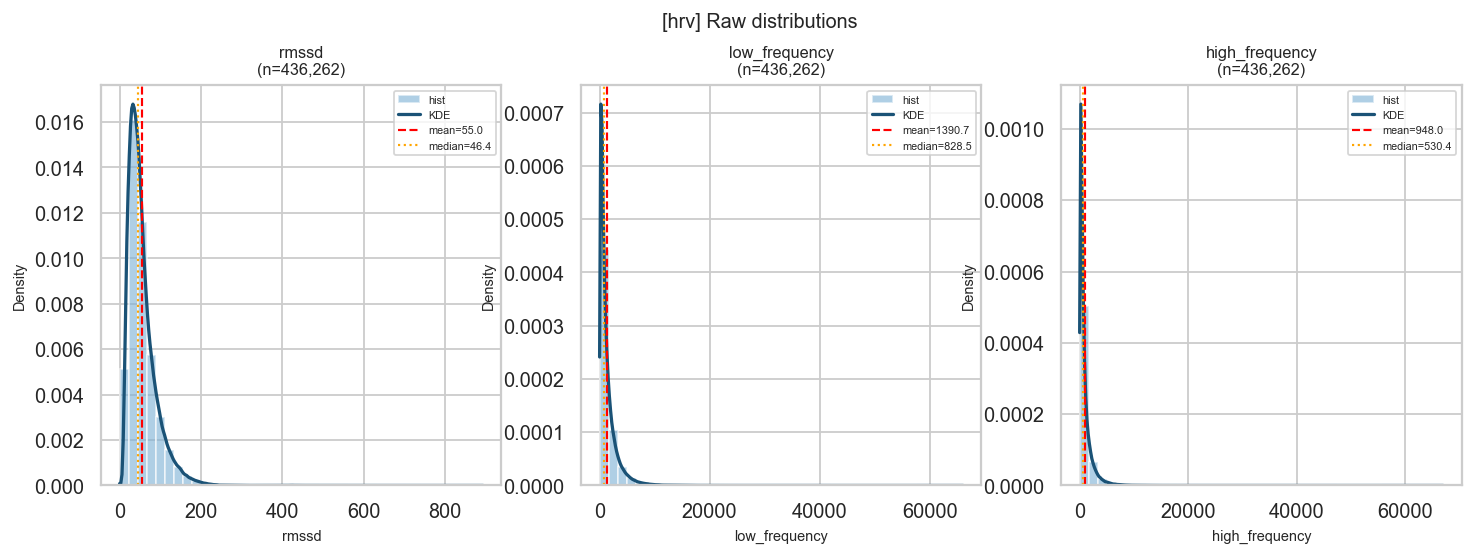

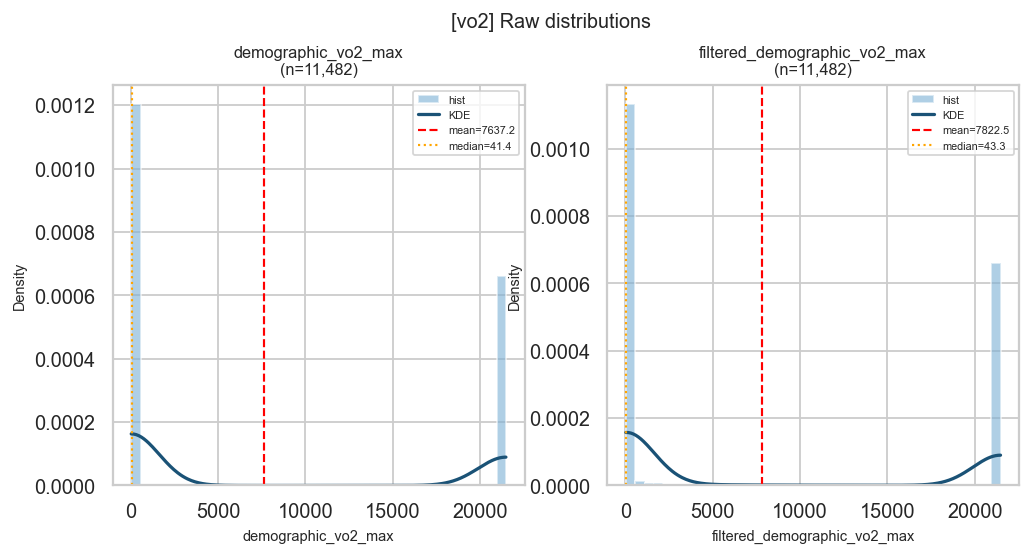

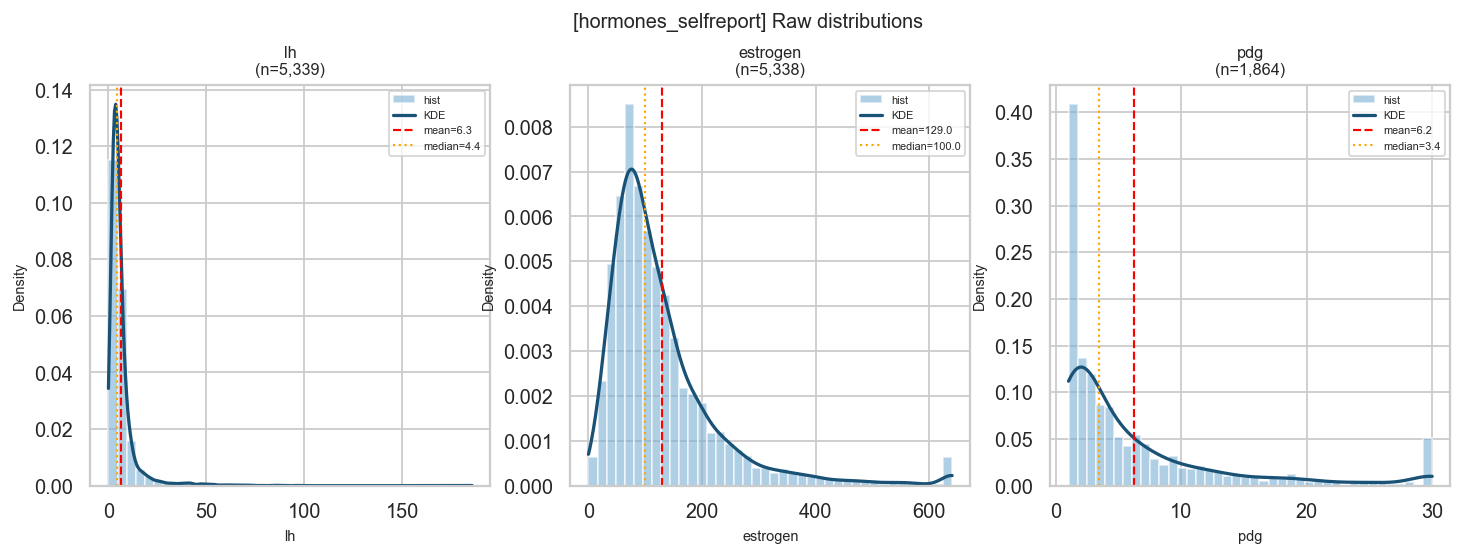

In [11]:
for tname, signals in TABLE_SIGNALS.items():
    df      = tables[tname]
    signals = [s for s in signals if s in df.columns]
    if not signals:
        continue

    ncols = min(len(signals), 4)
    fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4))
    if ncols == 1:
        axes = [axes]

    for ax, col in zip(axes, signals):
        data = df[col].dropna()

        # Histogram + KDE
        ax.hist(data, bins=40, density=True,
                color="#7bafd4", alpha=0.6, edgecolor="white", label="hist")
        try:
            kde = stats.gaussian_kde(data)
            xs  = np.linspace(data.min(), data.max(), 300)
            ax.plot(xs, kde(xs), color="#1a5276", linewidth=1.8, label="KDE")
        except Exception:
            pass

        # Annotate basic stats
        ax.axvline(data.mean(),   color="red",    linestyle="--",
                   linewidth=1.2, label=f"mean={data.mean():.1f}")
        ax.axvline(data.median(), color="orange", linestyle=":",
                   linewidth=1.2, label=f"median={data.median():.1f}")
        ax.set_title(f"{col}\n(n={len(data):,})", fontsize=9)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.legend(fontsize=6)

    plt.suptitle(f"[{tname}] Raw distributions", fontsize=11, y=1.02)
    # savefig(f"A_{tname}_dist.png")

In [12]:
# ═════════════════════════════════════════════
# B. PER-PARTICIPANT COVERAGE
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("B. PER-PARTICIPANT COVERAGE")
print("="*60)


B. PER-PARTICIPANT COVERAGE


In [13]:
# For each table that has id + day_in_study, count unique days per participant
coverage_summary = {}

In [14]:
for tname, df in tables.items():
    if ID_COL not in df.columns:
        continue
    day_col = DAY_COL
    # Some sleep tables use sleep_start_day_in_study
    if day_col not in df.columns:
        alt = [c for c in df.columns if "day_in_study" in c]
        if alt:
            day_col = alt[0]
        else:
            continue

    days_per_person = df.groupby(ID_COL)[day_col].nunique()
    coverage_summary[tname] = days_per_person

In [15]:
# ── B1. Heatmap: participants × tables (days of coverage) ───────────────────
cov_df = pd.DataFrame(coverage_summary).fillna(0).astype(int)
cov_df = cov_df.sort_index()   # sort by participant id

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5]),
 [Text(0.5, 0, 'active_minutes'),
  Text(1.5, 0, 'calories'),
  Text(2.5, 0, 'distance'),
  Text(3.5, 0, 'steps'),
  Text(4.5, 0, 'heart_rate'),
  Text(5.5, 0, 'glucose'),
  Text(6.5, 0, 'sleep'),
  Text(7.5, 0, 'sleep_score'),
  Text(8.5, 0, 'stress_score'),
  Text(9.5, 0, 'resting_heart_rate'),
  Text(10.5, 0, 'wrist_temperature'),
  Text(11.5, 0, 'computed_temperature'),
  Text(12.5, 0, 'respiratory_rate'),
  Text(13.5, 0, 'hrv'),
  Text(14.5, 0, 'exercise'),
  Text(15.5, 0, 'vo2'),
  Text(16.5, 0, 'hormones_selfreport')])

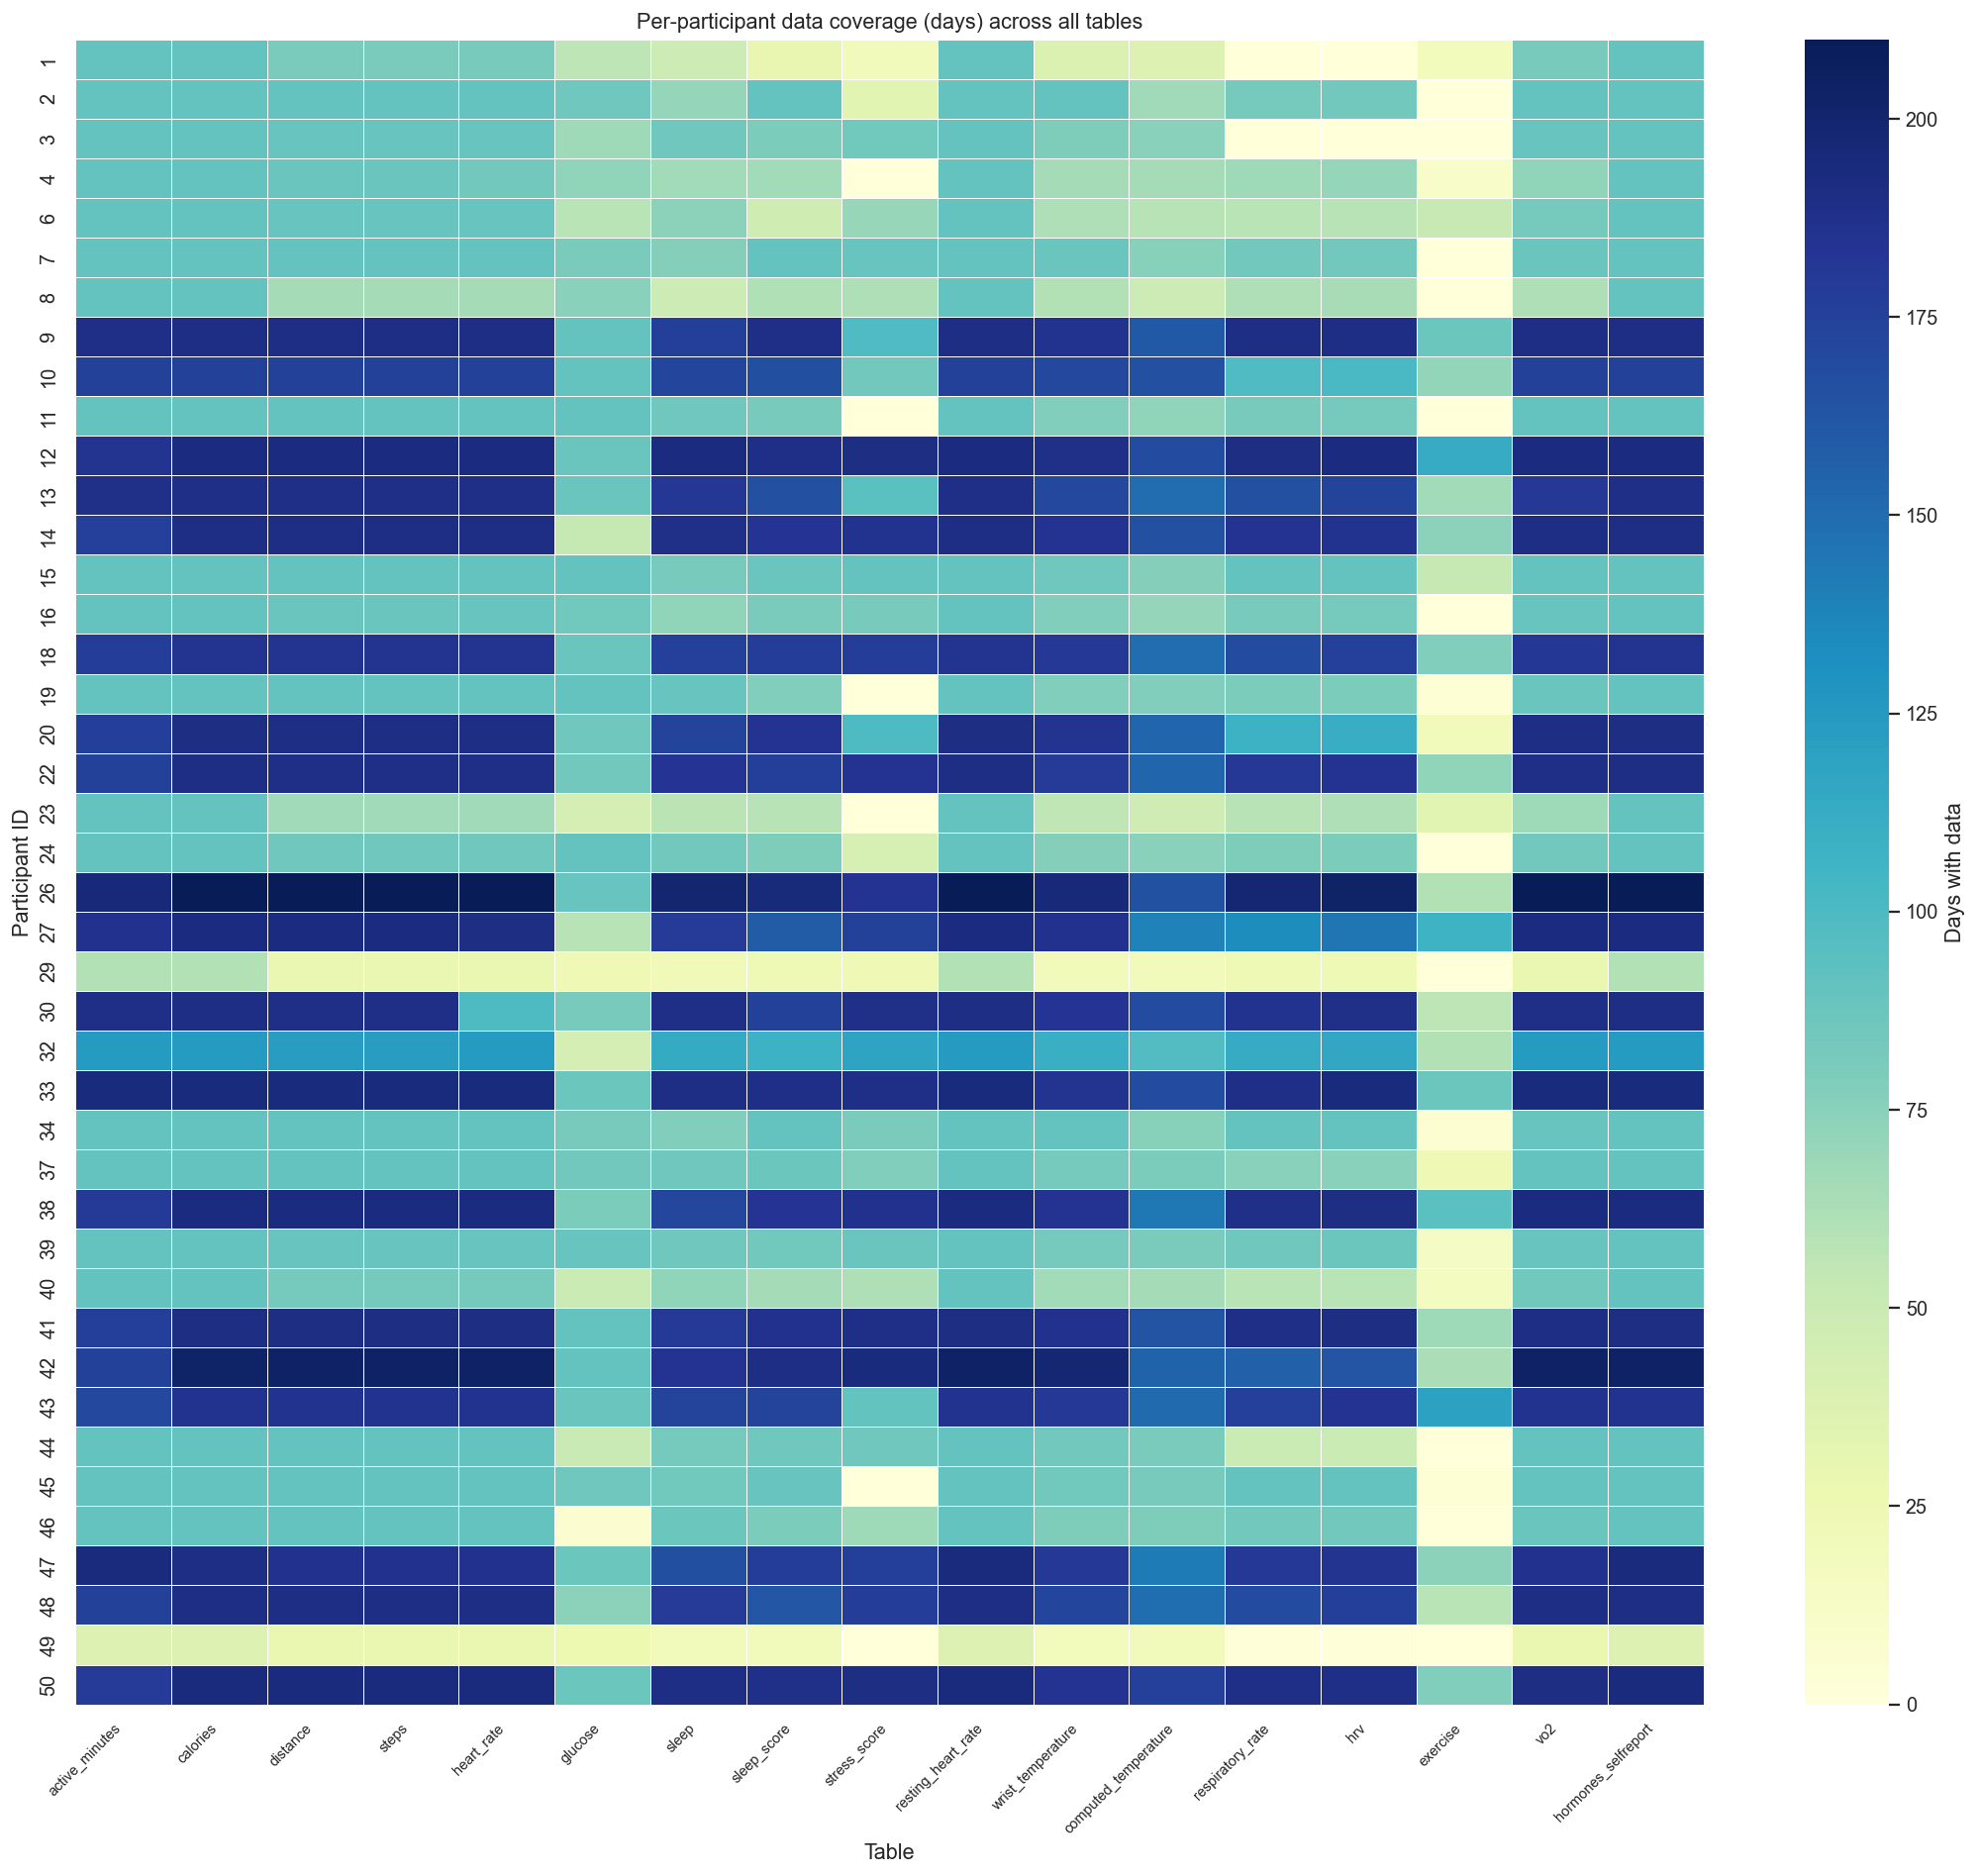

In [16]:
fig, ax = plt.subplots(figsize=(max(14, len(cov_df.columns) * 1.2),
                                max(6,  len(cov_df.index)   * 0.4)))
sns.heatmap(cov_df, ax=ax, cmap="YlGnBu", linewidths=0.3,
            cbar_kws={"label": "Days with data"})
ax.set_title("Per-participant data coverage (days) across all tables", fontsize=12)
ax.set_xlabel("Table")
ax.set_ylabel("Participant ID")
plt.xticks(rotation=45, ha="right", fontsize=8)
# savefig("B1_coverage_heatmap.png")

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]),
 [Text(1, 0, 'active_minutes'),
  Text(2, 0, 'calories'),
  Text(3, 0, 'distance'),
  Text(4, 0, 'steps'),
  Text(5, 0, 'heart_rate'),
  Text(6, 0, 'glucose'),
  Text(7, 0, 'sleep'),
  Text(8, 0, 'sleep_score'),
  Text(9, 0, 'stress_score'),
  Text(10, 0, 'resting_heart_rate'),
  Text(11, 0, 'wrist_temperature'),
  Text(12, 0, 'computed_temperature'),
  Text(13, 0, 'respiratory_rate'),
  Text(14, 0, 'hrv'),
  Text(15, 0, 'exercise'),
  Text(16, 0, 'vo2'),
  Text(17, 0, 'hormones_selfreport')])

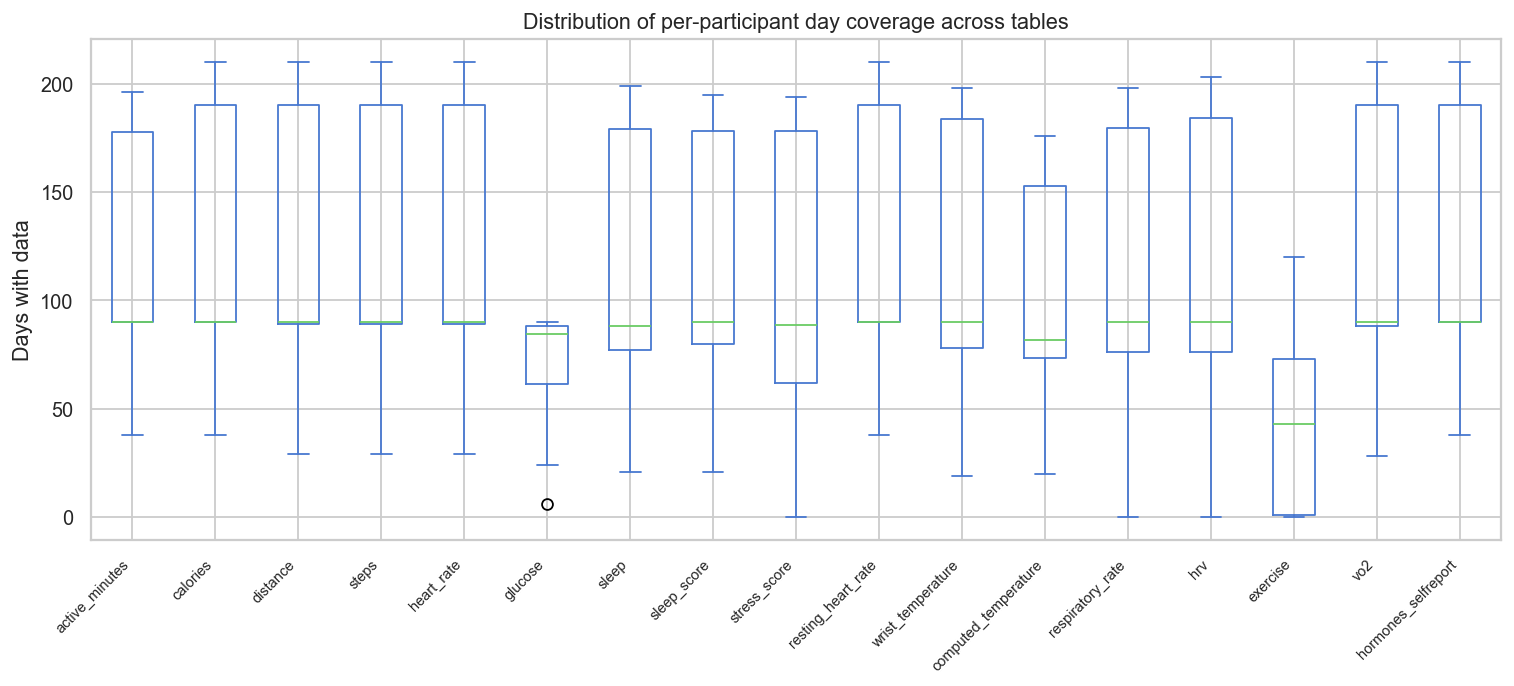

In [17]:
# ── B2. Box plots: spread of coverage per table ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cov_df.plot.box(ax=ax, vert=True, showfliers=True)
ax.set_title("Distribution of per-participant day coverage across tables")
ax.set_ylabel("Days with data")
plt.xticks(rotation=45, ha="right", fontsize=8)
# savefig("B2_coverage_boxplot.png")

In [18]:
# ── B3. Flag sparse participants (< 14 days in any key table) ────────────────
KEY_TABLES = ["stress_score", "sleep_score", "hormones_selfreport", "glucose"]
for kt in KEY_TABLES:
    if kt in coverage_summary:
        sparse = coverage_summary[kt][coverage_summary[kt] < 14]
        print(f"\n[{kt}] participants with < 14 days ({len(sparse)} total):")
        print(sparse.sort_values().to_string())


[stress_score] participants with < 14 days (0 total):
Series([], )

[sleep_score] participants with < 14 days (0 total):
Series([], )

[hormones_selfreport] participants with < 14 days (0 total):
Series([], )

[glucose] participants with < 14 days (1 total):
id
46    6


In [19]:
# ═════════════════════════════════════════════
# C. INTERVAL 1 vs INTERVAL 2 COMPARISON
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("C. INTERVAL 1 vs INTERVAL 2 COMPARISON")
print("="*60)


C. INTERVAL 1 vs INTERVAL 2 COMPARISON


NOTE: Interval 2 participants are a SUBSET of Interval 1 (by design).
So differences here reflect:
  (a) longitudinal change in the same people over ~2 years
  (b) seasonal effects (Jan-Apr vs Jul-Oct)
Both are scientifically interesting and should NOT be collapsed.

In [20]:
INTERVAL_SIGNALS = {
    "stress_score"       : "stress_score",
    "sleep_score"        : "overall_score",
    "resting_heart_rate" : "value",
    "glucose"            : "glucose_value",
    "steps"              : "steps",
    "hormones_selfreport": "lh",
}

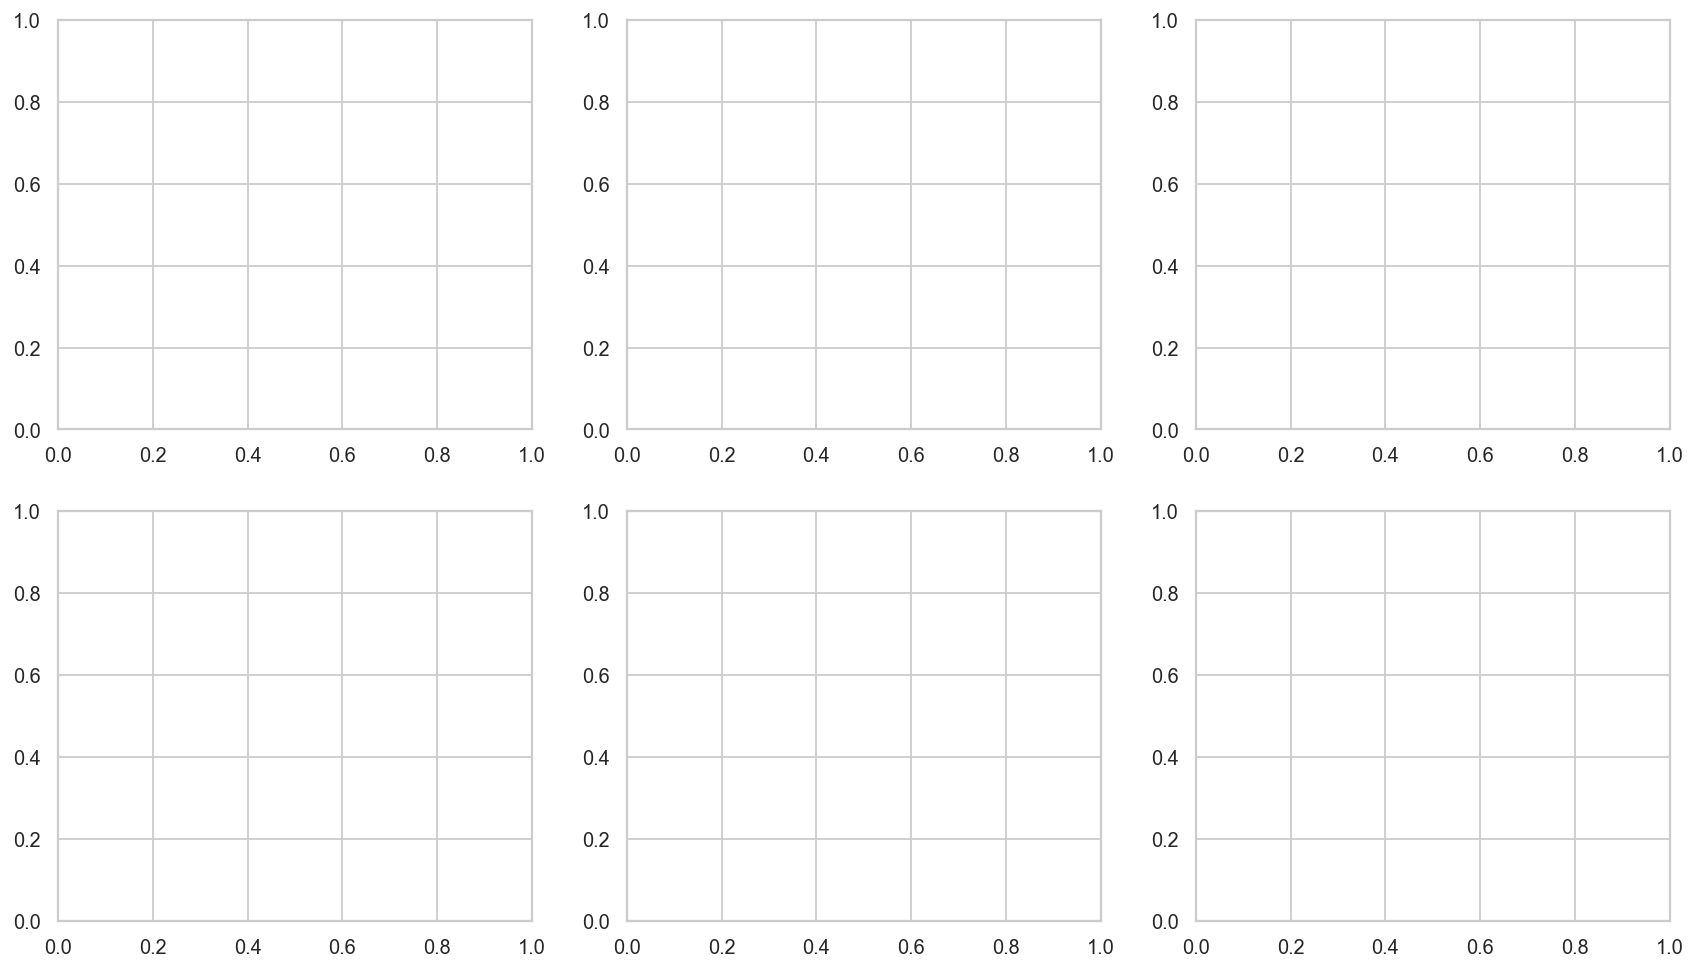

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

In [22]:
for ax, (tname, col) in zip(axes.flat, INTERVAL_SIGNALS.items()):
    df = tables[tname]
    if INTERVAL_COL not in df.columns or col not in df.columns:
        ax.set_visible(False)
        continue

    for iv, grp in df.groupby(INTERVAL_COL):
        data = grp[col].dropna()
        try:
            kde = stats.gaussian_kde(data)
            xs  = np.linspace(data.min(), data.max(), 300)
            ax.plot(xs, kde(xs), label=f"Interval {iv}",
                    linewidth=2)
        except Exception:
            ax.hist(data, bins=30, density=True, alpha=0.5,
                    label=f"Interval {iv}")

    # Mann-Whitney U test for distributional difference
    g1 = df[df[INTERVAL_COL] == 1][col].dropna()
    g2 = df[df[INTERVAL_COL] == 2][col].dropna()
    if len(g1) > 5 and len(g2) > 5:
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        ax.set_title(f"{tname}\n{col}  (p={p:.3f})", fontsize=8)
    else:
        ax.set_title(f"{tname} — {col}", fontsize=8)

    ax.legend(fontsize=7)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)

In [23]:
plt.suptitle("Interval 1 vs Interval 2 — key signal distributions\n"
             "(same participants, ~2 yr apart, different seasons)",
             fontsize=11, y=1.02)
# savefig("C_interval_comparison.png")

Text(0.5, 1.02, 'Interval 1 vs Interval 2 — key signal distributions\n(same participants, ~2 yr apart, different seasons)')

<Figure size 832x624 with 0 Axes>


Per-participant shift between intervals (stress score):
      I1_mean    I2_mean      delta
id                                 
27  76.807229   9.505263 -67.301966
42  77.309524  67.119658 -10.189866
38  81.573034  73.108911  -8.464123
41  81.752809  75.654206  -6.098603
47  78.025641  73.915094  -4.110547
14  75.265176  71.310000  -3.955176
50  79.715909  76.490909  -3.225000
33  79.931818  78.111111  -1.820707
18  67.231746  66.891304  -0.340442
12  71.397476  71.663462   0.265985
26  68.569231  68.960000   0.390769
32  68.697674  72.906250   4.208576
30  50.235955  54.754717   4.518762
22  57.882353  69.698113  11.815760
48  54.094118  74.600000  20.505882
1   13.536232        NaN        NaN
2   73.388889        NaN        NaN
3   47.102894        NaN        NaN
6   41.529183        NaN        NaN
7   74.079511        NaN        NaN
8   62.870293        NaN        NaN
9         NaN  72.715686        NaN
10        NaN  70.080460        NaN
13        NaN  62.938144        NaN
15  76.

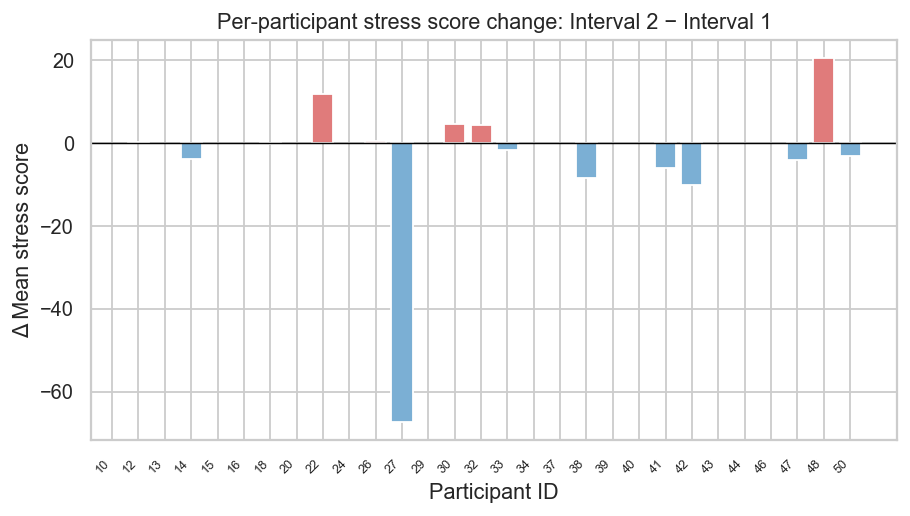

In [24]:
# ── C2. Participant-level: did individuals shift between intervals? ────────────
# For each participant present in both intervals, compute mean signal difference.
print("\nPer-participant shift between intervals (stress score):")
ss = tables["stress_score"]
if INTERVAL_COL in ss.columns and "stress_score" in ss.columns:
    pivot = (
        ss.groupby([ID_COL, INTERVAL_COL])["stress_score"]
          .mean()
          .unstack(INTERVAL_COL)
    )
    pivot.columns = ["I1_mean", "I2_mean"]
    pivot["delta"] = pivot["I2_mean"] - pivot["I1_mean"]
    print(pivot.sort_values("delta").to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(pivot.index.astype(str), pivot["delta"],
           color=["#e07b7b" if d > 0 else "#7bafd4"
                  for d in pivot["delta"]])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Per-participant stress score change: Interval 2 − Interval 1")
    ax.set_xlabel("Participant ID")
    ax.set_ylabel("Δ Mean stress score")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    # savefig("C2_stress_participant_shift.png")

In [25]:
# ═════════════════════════════════════════════
# D. MISSINGNESS MAP PER TABLE
# ═════════════════════════════════════════════
print("\n" + "="*60)
print("D. MISSINGNESS MAP PER TABLE")
print("="*60)


D. MISSINGNESS MAP PER TABLE



  [active_minutes] columns >30% missing: {'sedentary': 0.3339337175792507}

  [hormones_selfreport] columns >30% missing: {'pdg': 0.670613182541085}


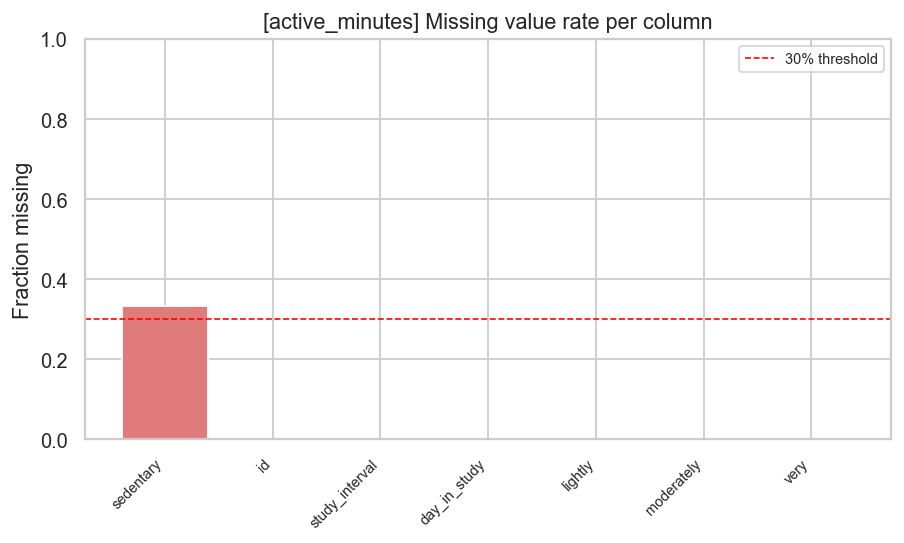

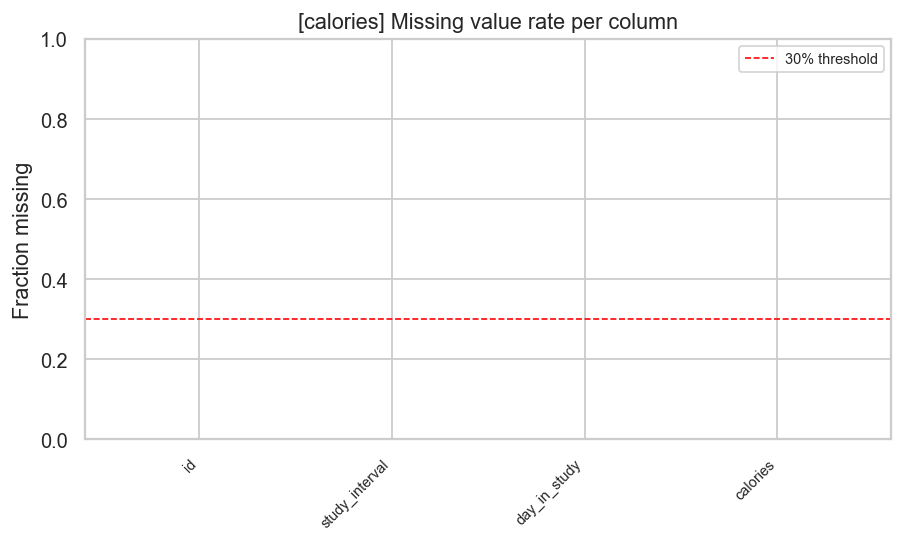

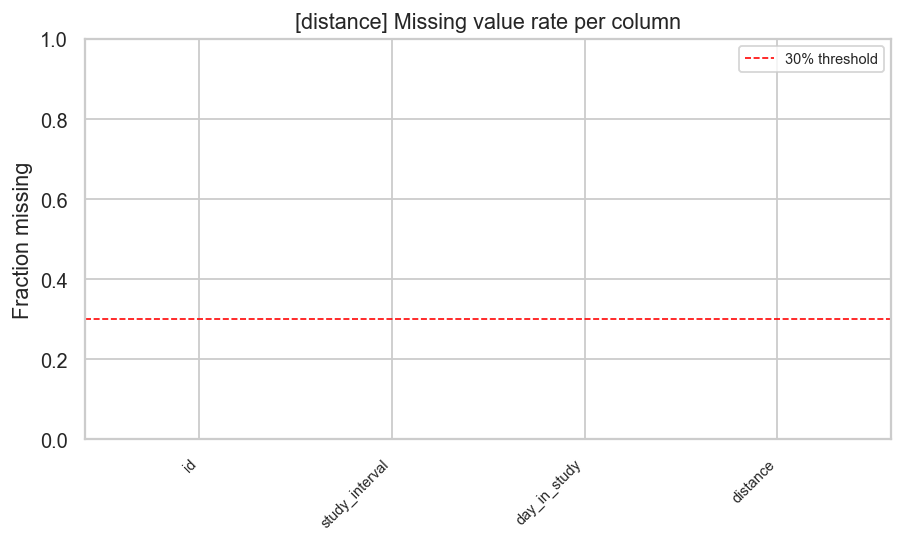

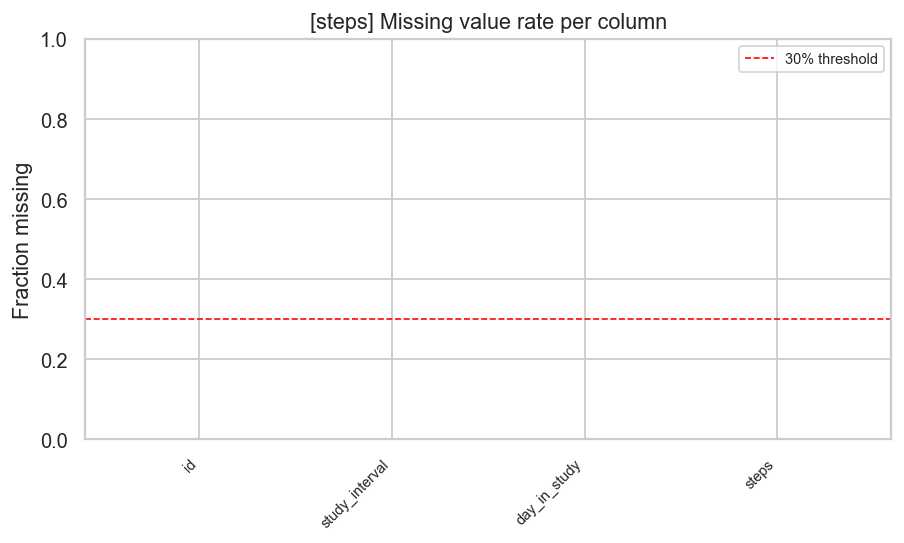

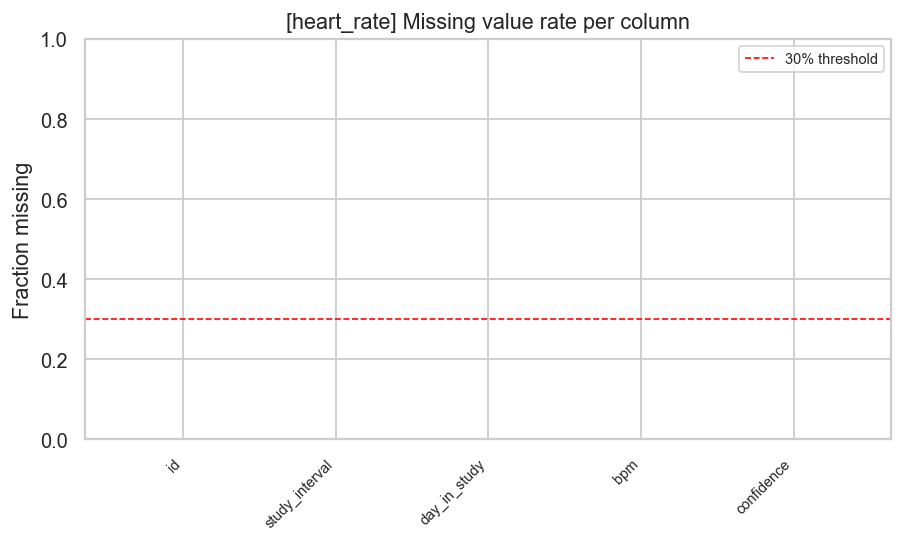

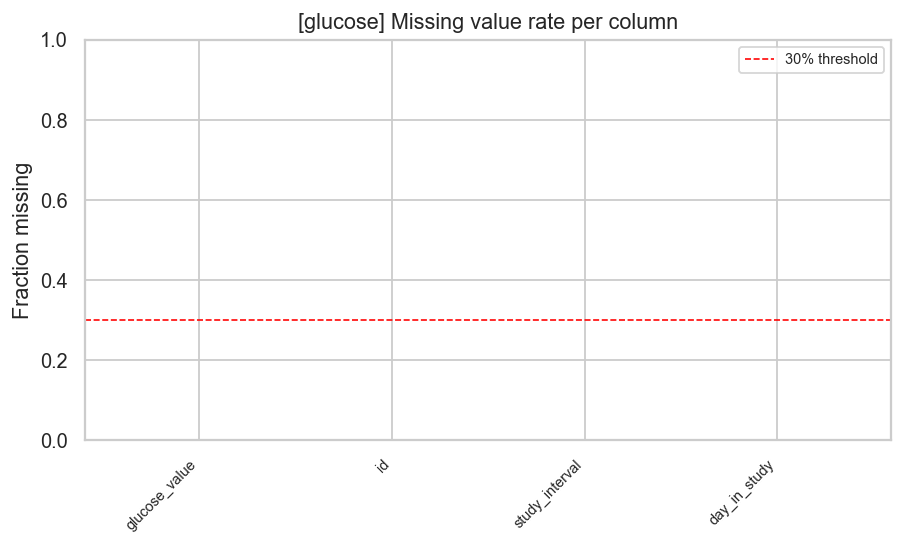

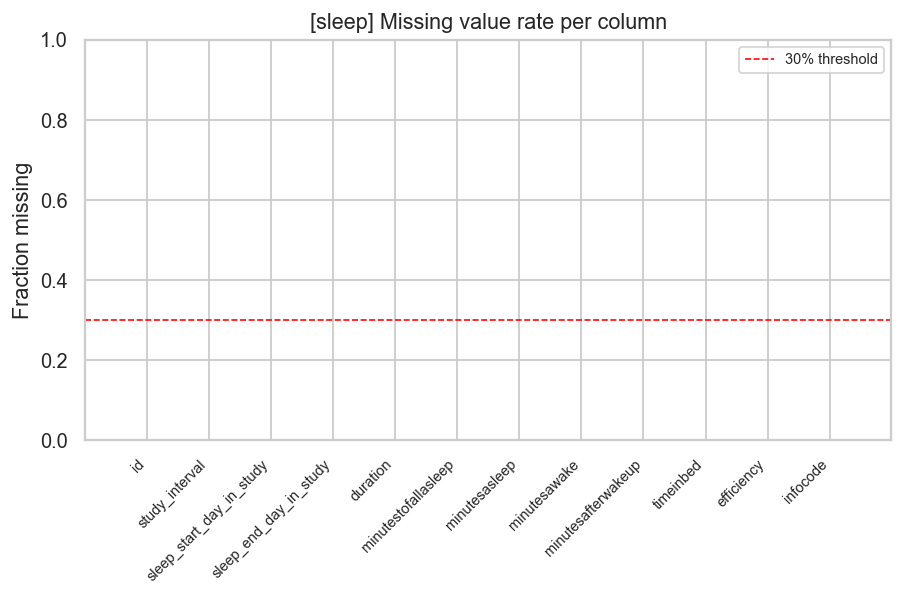

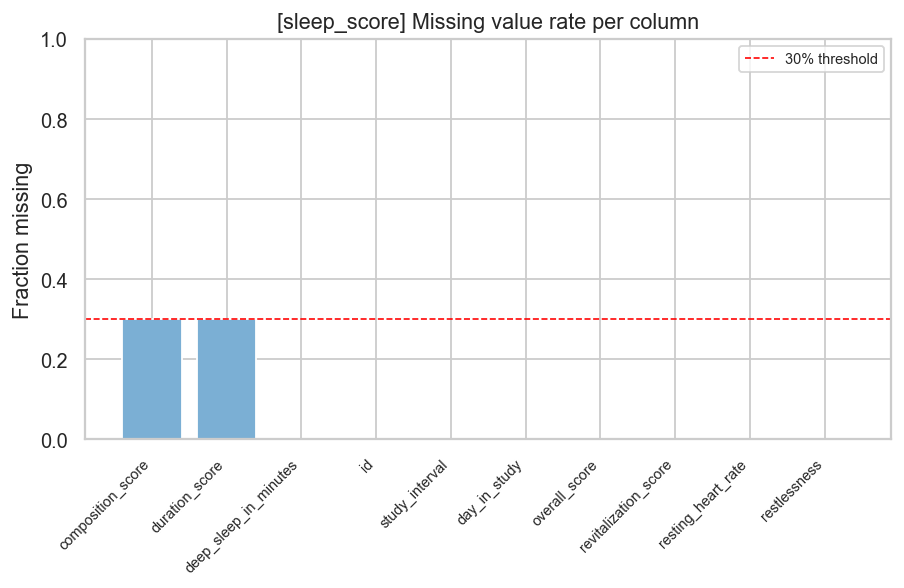

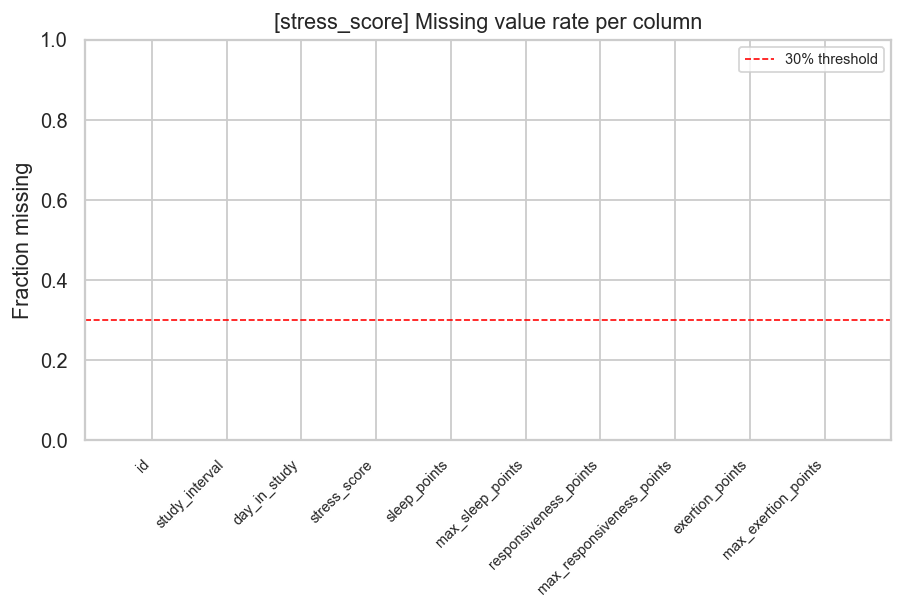

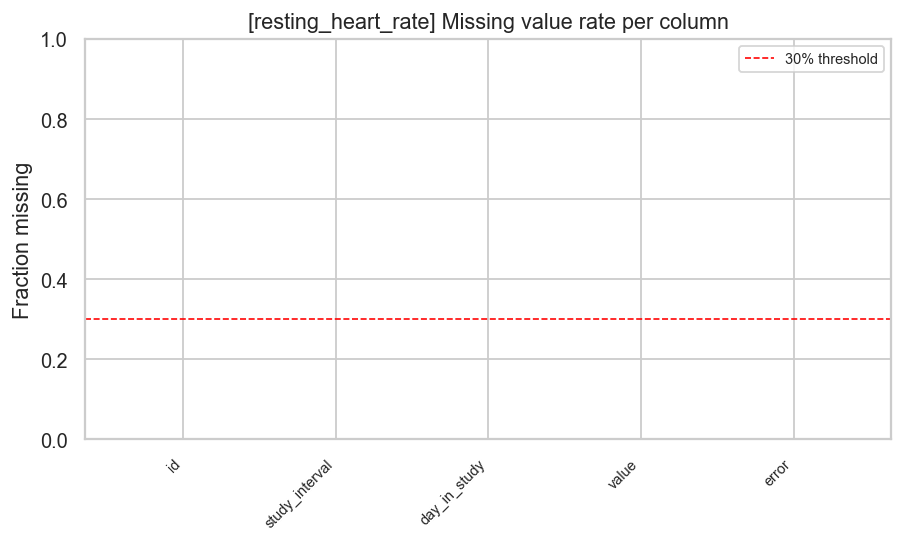

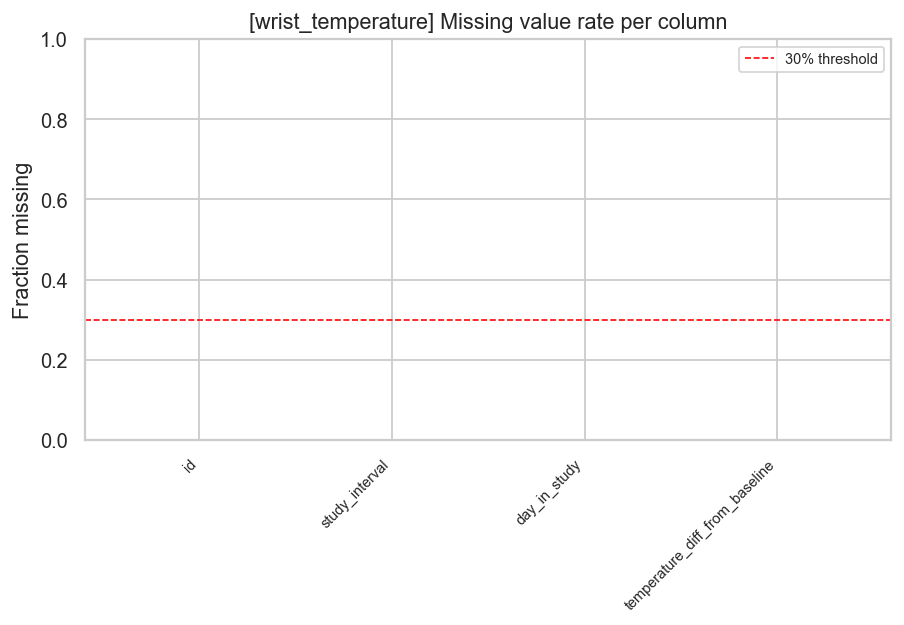

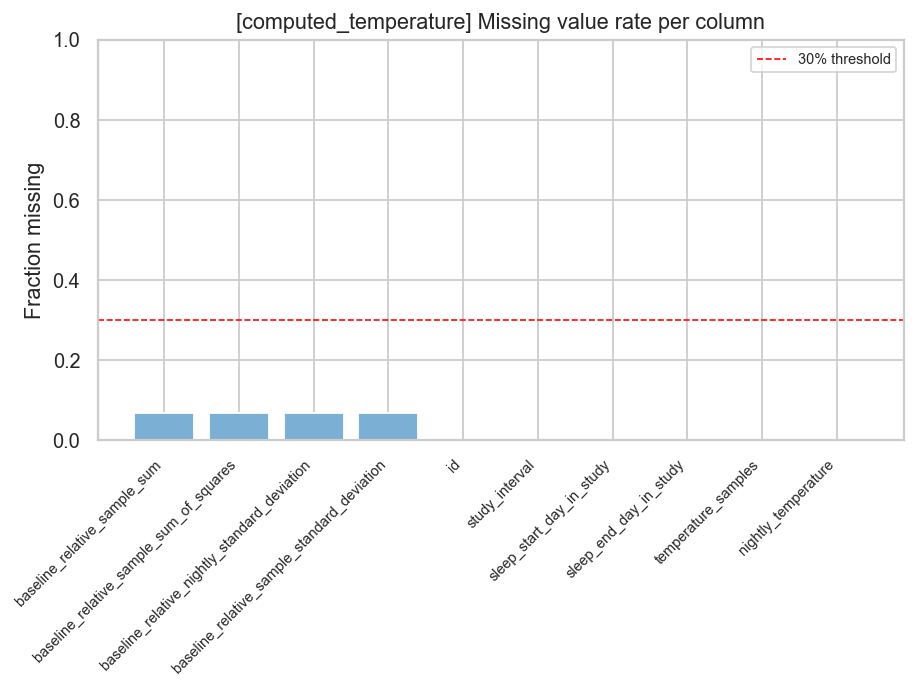

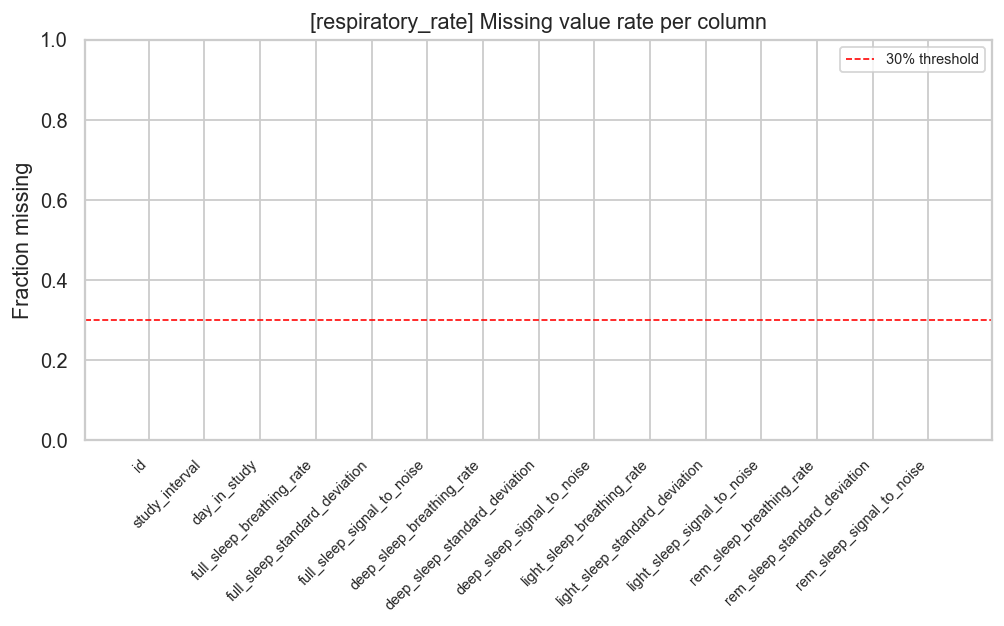

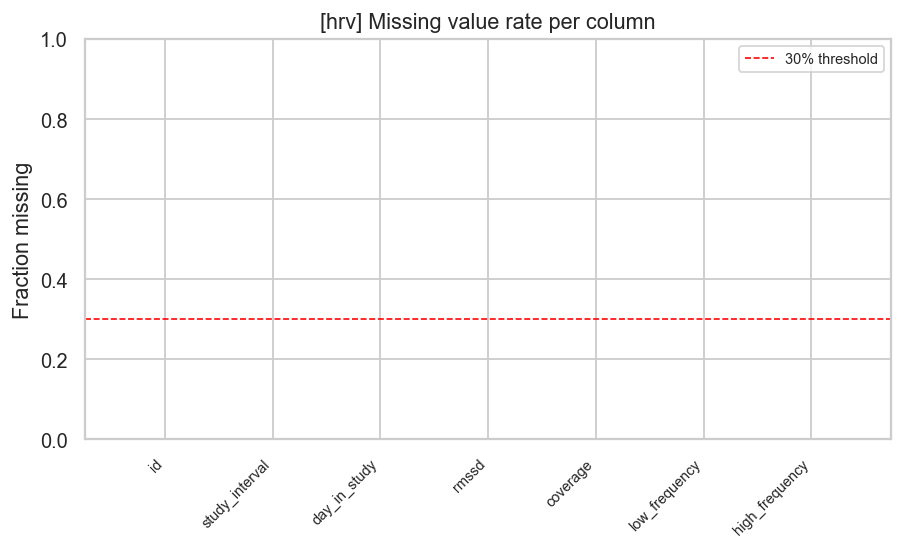

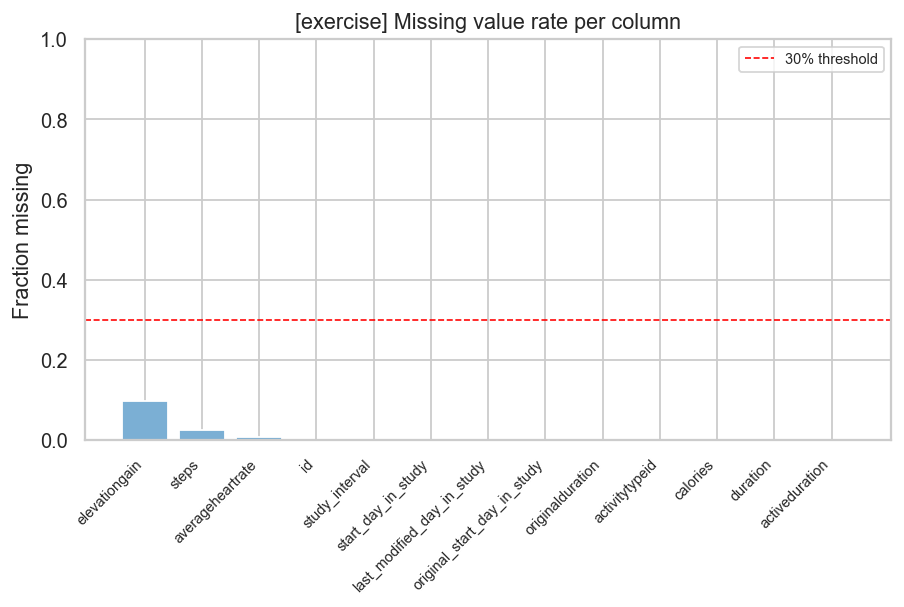

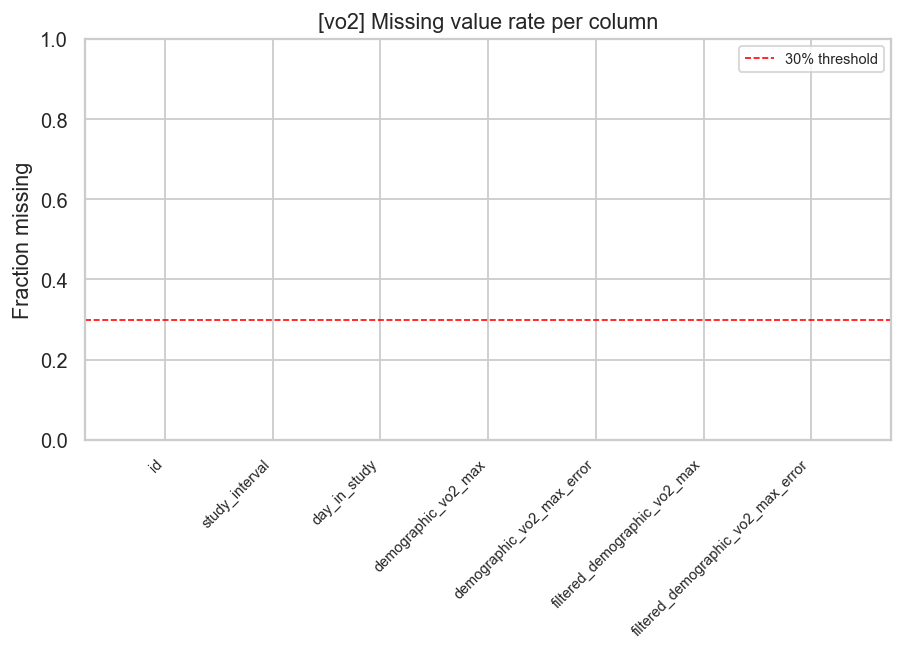

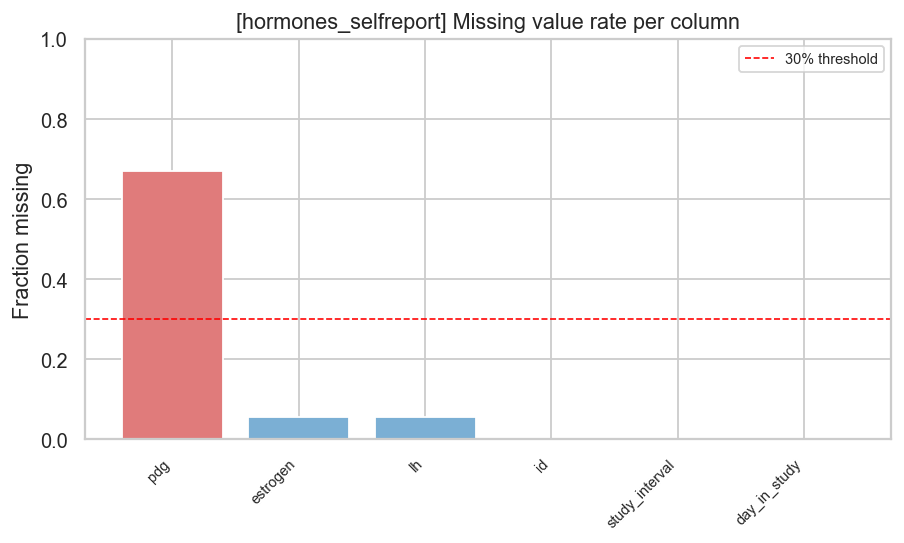

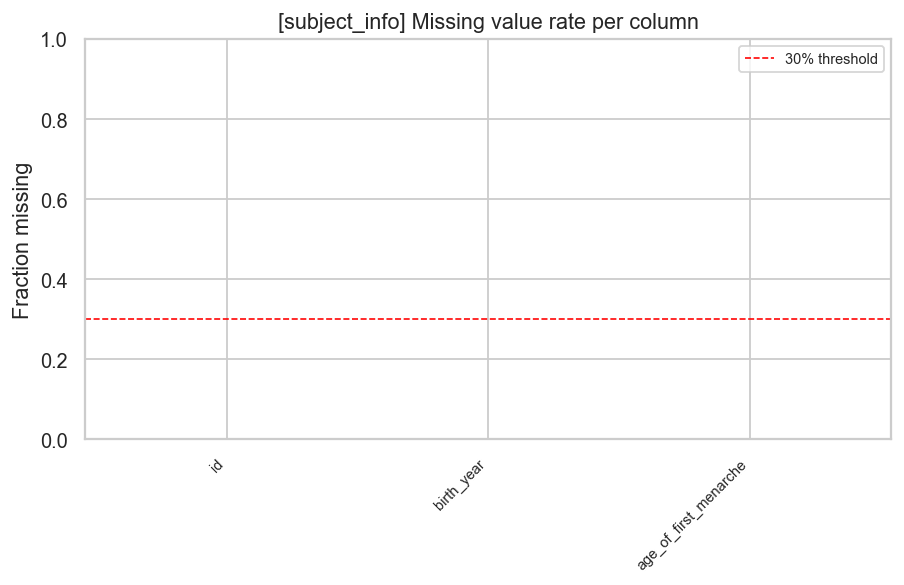

In [26]:
for tname, df in tables.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        continue

    miss_rate = df[numeric_cols].isnull().mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.6), 4))
    bars = ax.bar(miss_rate.index, miss_rate.values,
                  color=["#e07b7b" if v > 0.3 else "#7bafd4"
                         for v in miss_rate.values])
    ax.axhline(0.3, color="red", linestyle="--",
               linewidth=0.9, label="30% threshold")
    ax.set_title(f"[{tname}] Missing value rate per column")
    ax.set_ylabel("Fraction missing")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    # savefig(f"D_{tname}_missing.png")

    # Print any columns > 30% missing
    bad = miss_rate[miss_rate > 0.3]
    if not bad.empty:
        print(f"\n  [{tname}] columns >30% missing: {bad.to_dict()}")

In [27]:
print(f"\n✓ Script 1 complete. Figures saved to: {os.path.abspath(OUT_DIR)}")


✓ Script 1 complete. Figures saved to: /Users/kikkiliu/physionet.org/files/mcphases/eda_outputs/script1_prejoin
